In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [65]:
df=pd.read_csv("ASGN4/goog.csv")
df.head()

,Date,Open,High,Low,Close,Volume
0,12/19/2016,790.219971,797.659973,786.270020,794.200012,1225900
1,12/20/2016,796.760010,798.650024,793.270020,796.419983,925100
2,12/21/2016,795.840027,796.676025,787.099976,794.559998,1208700
3,12/22/2016,792.359985,793.320007,788.580017,791.260010,969100
4,12/23/2016,790.900024,792.739990,787.280029,789.909973,623400


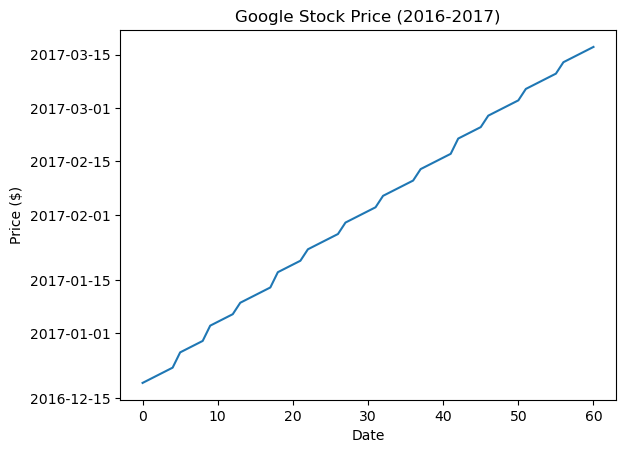

In [72]:
# --- Time Series Analysis ---
df['Date']=pd.to_datetime(df['Date'])
# 1. Plot the stock price trend
# plt.figure(figsize=(12, 6))
plt.plot(df['Date'], label='Google Stock Price')
plt.title('Google Stock Price (2016-2017)')
plt.xlabel('Date')
plt.ylabel('Price ($)')
# plt.legend()
# plt.grid()
plt.show()

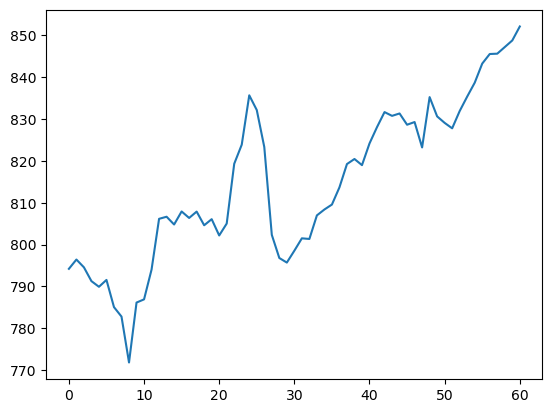

In [73]:
df=df['Close']
plt.plot(df)
df=np.array(df).reshape(-1,1)

In [74]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
df=scaler.fit_transform(np.array(df).reshape(-1,1))

In [75]:
training_size=int(len(df)*0.8)
df_train=df[:training_size,:]
df_test=df[training_size:len(df),:]
print(len(df_train) ,"-",len(df_test))

48 - 13


In [76]:
def createdataset(data,steps=4):
    x=[]
    y=[]
    for i in range(len(data)-steps):
        x.append(data[i:i+steps,0])
        y.append(data[i+steps,0])
    return np.array(x),np.array(y)

x_train,y_train=createdataset(df_train)
x_test,y_test=createdataset(df_test)
# print(x_train)
# print(y_train)
# print(x_test)
# print(y_test)

In [77]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,LSTM
model=Sequential()
model.add(LSTM(50,return_sequences=True,input_shape=(x_train.shape[1],1)))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(optimizer='adam',loss='mse',metrics=['accuracy'])
model.fit(x_train,y_train,epochs=50)

Epoch 1/50
2/2 [==============================] - 5s 13ms/step - loss: 0.2605 - accuracy: 0.0227
Epoch 2/50
2/2 [==============================] - 0s 9ms/step - loss: 0.2277 - accuracy: 0.0227
Epoch 3/50
2/2 [==============================] - 0s 8ms/step - loss: 0.1973 - accuracy: 0.0227
Epoch 4/50
2/2 [==============================] - 0s 8ms/step - loss: 0.1683 - accuracy: 0.0227
Epoch 5/50
2/2 [==============================] - 0s 8ms/step - loss: 0.1399 - accuracy: 0.0227
Epoch 6/50
2/2 [==============================] - 0s 8ms/step - loss: 0.1131 - accuracy: 0.0227
Epoch 7/50
2/2 [==============================] - 0s 8ms/step - loss: 0.0864 - accuracy: 0.0227
Epoch 8/50
2/2 [==============================] - 0s 8ms/step - loss: 0.0635 - accuracy: 0.0227
Epoch 9/50
2/2 [==============================] - 0s 8ms/step - loss: 0.0424 - accuracy: 0.0227
Epoch 10/50
2/2 [==============================] - 0s 7ms/step - loss: 0.0269 - accuracy: 0.0227
Epoch 11/50
2/2 [=====================

In [34]:
# help(mean_absolute_error)
model.evaluate(x_test,y_test)

1/1 [==============================] - 1s 811ms/step - loss: 690654.1875


690654.1875

In [35]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
y_pred=model.predict(x_test)
MAE=mean_absolute_error(y_test,y_pred)
MSe=mean_squared_error(y_test,y_pred)
print(f"MAE {MAE}  MSE {MSe}")

1/1 [==============================] - 1s 852ms/step
MAE 831.0328501873779  MSE 690654.1791519261


Text(0.5, 1.0, 'Actual vs Predicted')

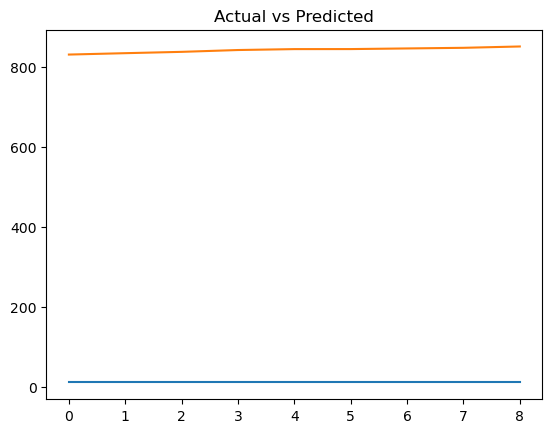

In [36]:
plt.plot(y_pred,label='Pred')
plt.plot(y_test,label='Actual')
plt.title("Actual vs Predicted")